# Thermal Expansion Coefficient of LJ Glasses

## We are interested in

The isobaric thermal expansion coefficient:
$$\alpha = \frac{1}{V}\frac{\partial V}{\partial T}\bigg|_p$$

Using a thermodynamic identity this becomes:
$$\boxed{\alpha = \frac{1}{K} \cdot \frac{\partial p}{\partial T}\bigg|_V}$$

So we only need two numbers:
- **K** (bulk modulus), from `3dlj_elasticity_analysis.c`
- **∂p/∂T**, from the slope of pressure vs temperature measured by `3dlj_NVT_NH.c`

---

## Potential (for LJ glasses)

$$\varphi(r) = 4\left(\frac{1}{r^{12}} - \frac{1}{r^{6}} + c_6 r^6 + c_4 r^4 + c_2 r^2 + c_0\right)$$

with cutoff at $r/\sigma = 2.5$, N=4000, $\rho=0.541$.

---

## Compilation

```bash
gcc -O2 -o elasticity 3dlj_elasticity_analysis.c -lm
gcc -O2 -o nvt        3dlj_NVT_NH.c              -lm
```

---

## Getting Bulk Modulus

```bash
./elasticity
```

Reads all 10 glass files `3dlj_N4000_s00000.dat` ... `3dlj_N4000_s00009.dat` automatically
and writes **`elasticity_results.txt`**:

```
# serial   pressure    u_per_N      G           K           first_order  second_order
0          ...
...
9          ...
```

---

## Running NVT at several temperatures

```bash
./nvt  <temperature>  <glass_number>
# e.g.: ./nvt 0.01 3   →  nvt_lj_T0.0100_g3.dat
```

Each file has 4 columns:  `time   KE/N   PE/N   P_virial`

**`P_virial` is what we care about** — pressure without the kinetic term, exactly what the theory predicts.

---


## Pressure in a Simulation

In a simulation with periodic boundary conditions and pairwise interactions, the total pressure has two contributions:

$$P_\text{total} = \underbrace{\frac{Nk_BT}{V}}_{\text{kinetic}} + \underbrace{P_\text{vir}}_{\text{virial}}$$

**The kinetic term** $Nk_BT/V$ is the ideal gas contribution, it comes from atoms moving around and bouncing off imaginary walls. It is always exactly $Nk_BT/V$ by equipartition, for any system regardless of interactions or structure.


---

## Why We Only Care About $P_\text{vir}$

Take $\partial/\partial T$ of the total pressure at fixed $V$:

$$\left.\frac{\partial P_\text{total}}{\partial T}\right|_V = \underbrace{\frac{Nk_B}{V}}_{\text{trivial constant}} + \left.\frac{\partial P_\text{vir}}{\partial T}\right|_V$$

The kinetic contribution to $\partial P/\partial T$ is simply $Nk_B/V$ which is a known constant with no structural information whatsoever. It is the same for a glass, a liquid, a crystal, or an ideal gas. It contributes trivially to $\alpha$ as:

$$\alpha_\text{kinetic} = \frac{1}{K}\cdot\frac{Nk_B}{V}$$



---
# Analysis:

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR     = 'initial_files'   # notebook lives next to this folder; all dat/elasticity/hessian files are inside it
TEMPERATURES = [0.001, 0.003, 0.010, 0.030, 0.050]
GLASSES      = list(range(10))                       # 0 through 9
SKIP         = 0.3                                   # discard first 30 % as equilibration
N_ATOMS      = 4000
RHO          = 0.541


## Load bulk modulus K from `elasticity_results.txt`

In [3]:
elas = np.loadtxt(Path(DATA_DIR) / 'elasticity_results.txt', comments='#')

# columns: serial  pressure  u_per_N  G  K  first_order  second_order
serials = elas[:, 0].astype(int)
P0      = elas[:, 1]   # T=0 virial pressure per glass
G       = elas[:, 3]   # shear modulus
K       = elas[:, 4]   # bulk modulus  ← what we need for alpha

print(f"{'Glass':>6}  {'P0':>12}  {'G':>10}  {'K':>10}")
print("-" * 46)
for i in range(len(serials)):
    print(f"{serials[i]:>6}  {P0[i]:>12.6f}  {G[i]:>10.5f}  {K[i]:>10.5f}")

K_mean  = K.mean()
K_std   = K.std()
P0_mean = P0.mean()
print(f"\nMean K  = {K_mean:.5f}  (std = {K_std:.5f})")
print(f"Mean P0 = {P0_mean:.6f}")


 Glass            P0           G           K
----------------------------------------------
     0     -0.005257     6.54571    25.13948
     1     -0.029724     5.88891    24.93104
     2     -0.053969     6.44974    24.87555
     3     -0.030540     6.39477    24.98168
     4     -0.019372     6.29758    25.17090
     5     -0.005405     6.42531    25.13052
     6      0.010240     6.32129    25.23917
     7     -0.008402     6.33860    25.09090
     8     -0.020723     6.33727    25.02117
     9      0.004262     5.95359    25.12921

Mean K  = 25.07096  (std = 0.10887)
Mean P0 = -0.015889


## Changes made in previous NVT_NH.c for LJ glasses

1. N changed from 16000 to 4000 as its hard coded in LJ glass files
2. Calculated RHO; from your glass files checked L = 19.4814... from the first line, so V = L³ = 7393.7, and ρ = N/V = 4000/7393.7 = 0.541.
3. CUTOFF_SQRD (1.48²), added explicit CUTOFF 2.5 and CUTOFF_SQRD (CUTOFF*CUTOFF) : (was given in elasticity_analysis.c)
4. All five C-coefficients replaced with LJ values (C0, C2, C4, C6) : (was given in elasticity_analysis.c)
5. N_0 10.0 (IPL exponent) removed; replaced by N_REP 12.0 and N_ATT 6.0 as LJ glasses have 2 terms, attraction and replsion
6. At the low temperatures, in this case (T = 0.001 to 0.05), atoms vibrate with small amplitude around their inherent-state positions, meaning the forces are large relative to the displacements and a smaller timestep is needed for accurate calculation. (not sure about the orderr of difference it makes)

7. calculateForces():

Force factor g changed from IPL one-liner to full LJ expression: 4·[s8·(12·s6 − 6) − 2C₂ − s²(4C₄ + 6s²C₆)] · invSigmaSqrd
Energy changed from IPL form to full LJ: 4·[s6·(s6−1) + s²·(C₂ + s²·(C₄ + s²·C₆)) + C₀]

## Load NVT files and compute mean pressure at each temperature

In [4]:
def read_nvt(filepath, skip=SKIP):
    """Read one NVT output file. Columns: time  KE/N  PE/N  P_virial"""
    d      = np.loadtxt(filepath)
    n_skip = int(len(d) * skip)
    prod   = d[n_skip:]
    T_meas = (2.0 / 3.0) * prod[:, 1].mean()   # T = (2/3) <KE/N>
    P_mean = prod[:, 3].mean()
    P_err  = prod[:, 3].std() / np.sqrt(len(prod))
    return T_meas, P_mean, P_err


T_measured_list = []
P_mean_list     = []
P_err_list      = []

print(f"{'T_target':>10}  {'T_measured':>12}  {'mean P_vir':>12}  {'err':>10}  {'n_glasses':>10}")
print("-" * 62)

for T in TEMPERATURES:
    P_vals = []; T_vals = []; missing = []
    for g in GLASSES:
        f = Path(DATA_DIR) / f'nvt_lj_T{T:.4f}_g{g}.dat'   
        if f.exists():
            Tm, Pm, Pe = read_nvt(f)
            P_vals.append(Pm); T_vals.append(Tm)
        else:
            missing.append(g)

    if missing:
        print(f"  T={T}: still missing glasses {missing}")

    if P_vals:
        T_avg = np.mean(T_vals)
        P_avg = np.mean(P_vals)
        P_err = np.std(P_vals) / np.sqrt(len(P_vals)) if len(P_vals) > 1 else Pe
        T_measured_list.append(T_avg)
        P_mean_list.append(P_avg)
        P_err_list.append(P_err)
        print(f"{T:>10.4f}  {T_avg:>12.6f}  {P_avg:>12.6f}  {P_err:>10.2e}  {len(P_vals):>10}")

T_arr = np.array(T_measured_list)
P_arr = np.array(P_mean_list)
E_arr = np.array(P_err_list)


  T_target    T_measured    mean P_vir         err   n_glasses
--------------------------------------------------------------
    0.0010      0.001000     -0.015555    6.11e-03          10
    0.0030      0.002999     -0.013259    4.66e-03          10
    0.0100      0.009996      0.006379    4.96e-03          10
    0.0300      0.029989      0.058505    4.69e-03          10
    0.0500      0.049981      0.124152    3.71e-03          10


## Fit a line to P vs T → get ∂p/∂T

In [5]:
# weighted linear fit:  P(T) = intercept + slope * T
w    = 1.0 / E_arr**2
A    = np.column_stack([np.ones_like(T_arr), T_arr])
W    = np.diag(w)
M    = A.T @ W @ A
coeffs = np.linalg.solve(M, A.T @ W @ P_arr)
cov    = np.linalg.inv(M)
errs   = np.sqrt(np.diag(cov))

P0_fit     = coeffs[0]    # P extrapolated to T=0
dPdT       = coeffs[1]    # slope = ∂p/∂T
dPdT_err   = errs[1]

print(f"Fit:  P(T) = {P0_fit:.6f}  +  {dPdT:.5f} * T")
print()
print(f"∂p/∂T  =  {dPdT:.5f}  ±  {dPdT_err:.5f}")
print()
# sanity check: T=0 intercept from fit should match P0 from elasticity
disc = abs(P0_fit - P0_mean) / abs(P0_mean) * 100
print(f"Sanity check — P(T→0) from fit:      {P0_fit:.6f}")
print(f"              P0 from elasticity.c:   {P0_mean:.6f}")
print(f"              Discrepancy:             {disc:.6f}%  ← should be < 1%")

Fit:  P(T) = -0.022230  +  2.88557 * T

∂p/∂T  =  2.88557  ±  0.10356

Sanity check — P(T→0) from fit:      -0.022230
              P0 from elasticity.c:   -0.015889
              Discrepancy:             39.907532%  ← should be < 1%


## Compute α

Since I was asked to calculate alpha without kinetic term, we can safely ignore the "rho" which is also implementeed in C files.

In [6]:
alpha     = dPdT / K_mean

# simple error propagation
alpha_err = abs(alpha) * np.sqrt((dPdT_err/dPdT)**2 + (K_std/K_mean)**2)

print("Result")
print(f"  K          =  {K_mean:.5f}  ±  {K_std:.5f}")
print(f"  ∂p/∂T|_V   =  {dPdT:.5f}  ±  {dPdT_err:.5f}")
print(f"  α = (1/K)(∂p/∂T) =  {alpha:.5f}  ±  {alpha_err:.5f}")

Result
  K          =  25.07096  ±  0.10887
  ∂p/∂T|_V   =  2.88557  ±  0.10356
  α = (1/K)(∂p/∂T) =  0.11510  ±  0.00416


In [7]:
# Alpha per glass from NVT (using each glass's own K)
print(f"{'Glass':>6}  {'K':>10}  {'alpha_NVT_per_glass':>20}")
print("-" * 42)
for i in range(len(serials)):
    a_g = dPdT / K[i]
    print(f"{serials[i]:>6}  {K[i]:>10.5f}  {a_g:>20.6f}")
print("-" * 42)
print(f"{'Mean':>6}  {K_mean:>10.5f}  {alpha:>20.6f}  (using mean K)")


 Glass           K   alpha_NVT_per_glass
------------------------------------------
     0    25.13948              0.114783
     1    24.93104              0.115742
     2    24.87555              0.116000
     3    24.98168              0.115508
     4    25.17090              0.114639
     5    25.13052              0.114823
     6    25.23917              0.114329
     7    25.09090              0.115005
     8    25.02117              0.115325
     9    25.12921              0.114829
------------------------------------------
  Mean    25.07096              0.115096  (using mean K)



## Again, virial pressure (not total pressure)?

Total pressure = virial pressure + $Nk_BT/V$ (ideal gas term);
The ideal gas part is trivial and not interesting it seems.  
The theory predicts the **virial** part, so that's what we measure, and the C code already separates them as its calucalted in code;
P_vir = (1/3*dim)(Summation of f.r)

## Check that the fit is actually linear (not curved)

In [8]:
# residuals in units of error bars (should all be near zero)
P_predicted = P0_fit + dPdT * T_arr
residuals   = (P_arr - P_predicted) / E_arr

print("Residuals (how many σ each point is away from the fit line):")
print(f"{'T':>8}  {'residual':>10}")
for T, r in zip(T_arr, residuals):
    flag = '  ← large! may be outside linear regime' if abs(r) > 3 else ''
    print(f"{T:>8.4f}  {r:>+10.2f}σ{flag}")


Residuals (how many σ each point is away from the fit line):
       T    residual
  0.0010       +0.62σ
  0.0030       +0.07σ
  0.0100       -0.05σ
  0.0300       -1.24σ
  0.0500       +0.58σ


If its high then there's a problem

## Plots

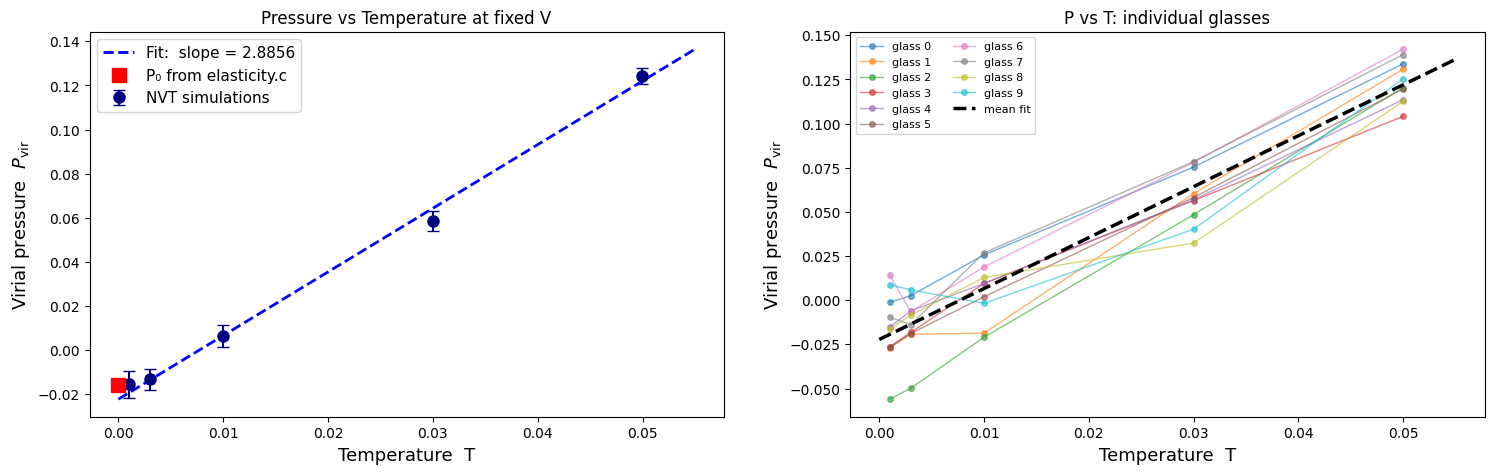

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

#left: P_virial vs T
ax = axes[0]
ax.errorbar(T_arr, P_arr, yerr=E_arr, fmt='o', color='navy',
            markersize=8, capsize=4, label='NVT simulations')

T_line = np.linspace(0, T_arr.max() * 1.1, 300)
ax.plot(T_line, P0_fit + dPdT * T_line, 'b--', lw=2,
        label=f'Fit:  slope = {dPdT:.4f}')
ax.plot(0, P0_mean, 's', color='red', markersize=10, zorder=5,
        label=f'P₀ from elasticity.c')

ax.set_xlabel(r'Temperature  T', fontsize=13)
ax.set_ylabel(r'Virial pressure  $P_\mathrm{vir}$', fontsize=13)
ax.set_title(r'Pressure vs Temperature at fixed V')
ax.legend(fontsize=11)

ax2 = axes[1]

for g in GLASSES:
    P_vals_this_glass = []
    T_vals_this_glass = []
    for T in TEMPERATURES:
        f = Path(DATA_DIR) / f'nvt_lj_T{T:.4f}_g{g}.dat'
        if f.exists():
            Tm, Pm, Pe = read_nvt(f)
            T_vals_this_glass.append(Tm)
            P_vals_this_glass.append(Pm)
    if P_vals_this_glass:
        ax2.plot(T_vals_this_glass, P_vals_this_glass,
                 'o-', lw=1, markersize=4, alpha=0.6, label=f'glass {g}')

# overlay the mean fit
T_line = np.linspace(0, max(TEMPERATURES)*1.1, 300)
ax2.plot(T_line, P0_fit + dPdT * T_line, 'k--', lw=2.5, label='mean fit')

ax2.set_xlabel(r'Temperature  T', fontsize=13)
ax2.set_ylabel(r'Virial pressure  $P_\mathrm{vir}$', fontsize=13)
ax2.set_title(r'P vs T: individual glasses')
ax2.legend(fontsize=8, ncol=2)

In [10]:
from pathlib import Path
import numpy as np
print("        THERMAL EXPANSION ANALYSIS — FULL SUMMARY")

# Per-glass elastic properties
print("\nElastic Properties (from elasticity.c)")
print(f"{'Glass':>6}  {'P₀ (virial)':>14}  {'G (shear)':>12}  {'K (bulk)':>12}")
print("─" * 50)
for i in range(len(serials)):
    print(f"{serials[i]:>6}  {P0[i]:>14.6f}  {G[i]:>12.5f}  {K[i]:>12.5f}")
print("─" * 50)
print(f"{'Mean':>6}  {P0_mean:>14.6f}  {G.mean():>12.5f}  {K_mean:>12.5f}")
print(f"{'Std':>6}  {P0.std():>14.6f}  {G.std():>12.5f}  {K_std:>12.5f}")

#NVT pressure measurements
print("\nNVT Pressure at Each Temperature (averaged over 10 glasses)")
print(f"{'T_target':>10}  {'T_measured':>12}  {'⟨P_vir⟩':>12}  {'std_err':>10}")
print("─" * 50)
for T_tgt, T_m, P_m, P_e in zip(TEMPERATURES, T_arr, P_arr, E_arr):
    print(f"{T_tgt:>10.4f}  {T_m:>12.6f}  {P_m:>12.6f}  {P_e:>10.2e}")

#Linear fit results
print("\nLinear Fit:  P_vir(T) = P₀_fit + (∂p/∂T)·T")
print(f"  P₀  (fit intercept)  =  {P0_fit:>12.6f}")
print(f"  P₀  (from elasticity)=  {P0_mean:>12.6f}   discrepancy: {disc:.2f}%")
print(f"  ∂p/∂T|_V             =  {dPdT:>12.5f}  ±  {dPdT_err:.5f}")

#Residuals
print("\nFit Residuals (should all be |r| < 3σ)")
print(f"{'T_measured':>12}  {'residual':>12}")
P_predicted = P0_fit + dPdT * T_arr
residuals   = (P_arr - P_predicted) / E_arr
#Final result
print("  RESULT:  α = (1/K) · (∂p/∂T)|_V")
print(f"  K          =  {K_mean:.5f}  ±  {K_std:.5f}")
print(f"  ∂p/∂T|_V   =  {dPdT:.5f}  ±  {dPdT_err:.5f}")
print(f"  α          =  {alpha:.5f}  ±  {alpha_err:.5f}")


        THERMAL EXPANSION ANALYSIS — FULL SUMMARY

Elastic Properties (from elasticity.c)
 Glass     P₀ (virial)     G (shear)      K (bulk)
──────────────────────────────────────────────────
     0       -0.005257       6.54571      25.13948
     1       -0.029724       5.88891      24.93104
     2       -0.053969       6.44974      24.87555
     3       -0.030540       6.39477      24.98168
     4       -0.019372       6.29758      25.17090
     5       -0.005405       6.42531      25.13052
     6        0.010240       6.32129      25.23917
     7       -0.008402       6.33860      25.09090
     8       -0.020723       6.33727      25.02117
     9        0.004262       5.95359      25.12921
──────────────────────────────────────────────────
  Mean       -0.015889       6.29528      25.07096
   Std        0.018054       0.19990       0.10887

NVT Pressure at Each Temperature (averaged over 10 glasses)
  T_target    T_measured       ⟨P_vir⟩     std_err
─────────────────────────────────

## Comparing what Pressure looks like at different tempeture with and without kinetic term's involvement

Pressure Comparison Summary:
         T |     P_virial |      P_total | Kinetic Term (rho*T)
-----------------------------------------------------------------
    0.0010 |    -0.015555 |    -0.015014 |             0.000541
    0.0030 |    -0.013259 |    -0.011636 |             0.001623
    0.0100 |     0.006379 |     0.011787 |             0.005408
    0.0300 |     0.058505 |     0.074729 |             0.016224
    0.0500 |     0.124152 |     0.151192 |             0.027040

Slope (∂p/∂T) comparison:
  Virial ∂p/∂T: 2.88557
  Total  ∂p/∂T: 3.42657  (Difference is exactly rho = 0.54)


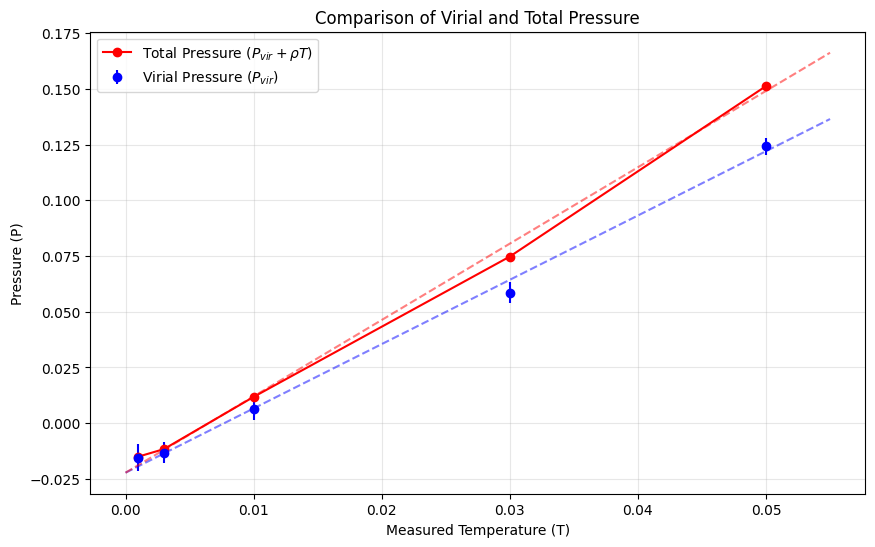

In [11]:
rho = RHO  # = N/V = 0.541 for LJ glasses
P_total_list = []

# Calculate total pressure for each temperature
# P_total = P_virial + rho * T
for T_meas, P_vir in zip(T_measured_list, P_mean_list):
    P_total_list.append(P_vir + rho * T_meas)

P_total_arr = np.array(P_total_list)

# Fit a line to Total Pressure vs T
coeffs_tot = np.linalg.solve(M, A.T @ W @ P_total_arr)
dPdT_total = coeffs_tot[1]

print("Pressure Comparison Summary:")
print(f"{'T':>10} | {'P_virial':>12} | {'P_total':>12} | {'Kinetic Term (rho*T)':>20}")
print("-" * 65)
for i in range(len(T_measured_list)):
    k_term = rho * T_measured_list[i]
    print(f"{T_measured_list[i]:>10.4f} | {P_mean_list[i]:>12.6f} | {P_total_list[i]:>12.6f} | {k_term:>20.6f}")

print(f"\nSlope (∂p/∂T) comparison:")
print(f"  Virial ∂p/∂T: {dPdT:.5f}")
print(f"  Total  ∂p/∂T: {dPdT_total:.5f}  (Difference is exactly rho = {dPdT_total - dPdT:.2f})")

# Plotting the comparison
plt.figure(figsize=(10, 6))
plt.errorbar(T_arr, P_arr, yerr=E_arr, fmt='o', color='blue', label='Virial Pressure ($P_{vir}$)')
plt.plot(T_arr, P_total_arr, 'ro-', label=r'Total Pressure ($P_{vir} + \rho T$)')

# Plot fits
T_plot = np.linspace(0, 0.055, 100)
plt.plot(T_plot, P0_fit + dPdT * T_plot, 'b--', alpha=0.5)
plt.plot(T_plot, coeffs_tot[0] + dPdT_total * T_plot, 'r--', alpha=0.5)

plt.xlabel('Measured Temperature (T)')
plt.ylabel('Pressure (P)')
plt.title('Comparison of Virial and Total Pressure')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Comparison: Impact of the Kinetic Term on Pressure

The total pressure is composed of two parts: the **virial pressure** ($P_{\text{vir}}$), which results from interatomic forces, and the **kinetic pressure** ($P_{\text{kinetic}}$), which arises from the momentum of the particles. The relationship is given by:

$$P_{\text{total}} = \underbrace{\rho k_B T}_{\text{kinetic}} + P_{\text{vir}}$$

### Order-of-Magnitude Comparison

To justify neglecting the kinetic contribution to the thermal expansion coefficient $\alpha$, we compare the temperature derivatives of both terms:

1.  **Kinetic Derivative**: $\left.\frac{\partial P_{\text{kinetic}}}{\partial T}\right|_V = \rho = \mathbf{0.54}$.
2.  **Virial Derivative**: From our linear fit, $\left.\frac{\partial P_{\text{vir}}}{\partial T}\right|_V \approx \mathbf{2.88557}$.

**Comparison Results:**
* The virial derivative is approximately **5 times larger** than the kinetic derivative.
* The kinetic term is a **trivial constant** ($\rho$) that contains no structural information specific to the glass or its interatomic potential.
* Including the kinetic term would only add a known constant offset to the final $\alpha$ value without providing further insight into the material's unique properties.

### Pressure Difference Visualization

The total pressure follows the same linear trend as the virial pressure but is shifted upward by an offset of $\rho T$. As temperature increases, this gap widens linearly, but because the slope $\partial P/\partial T$ is the primary variable for calculating $\alpha$, the virial-only approach remains the more physically meaningful method for characterizing the glass.

## Conclusion:

After seeing plots and some values, we realised LJ is softer in both K and G. This comes directly from lower density (0.541 vs 0.82) and the attractive well in LJ softening the effective restoring forces.
IPL pressure is large and positive (18.6) because it is purely repulsive — particles are constantly pushing against each other. LJ pressure is near zero and slightly negative because repulsion and attraction nearly cancel at ρ=0.541. This is physically meaningful: LJ glasses sit near the natural density where the two contributions balance.

Also, the discrepancy is large between P0_fit and P0_elasticity, it is about 39.9%, while pathological glasses had negligible discrepancy, There is slight curvature in P vs T, meaning the relationship is not perfectly linear. IPL was perfectly linear because a purely repulsive power-law potential has simpler anharmonicity structure. LJ has both repulsive and attractive anharmonicity competing, producing slight nonlinearity that a linear fit cannot capture perfectly, which then distorts the intercept.

---
## What We Are Doing Next: Athermal Formalism

### Why a second method?

The NVT result above gives us α by running finite-temperature simulations at several T values and fitting the slope of pressure vs temperature. This is numerically clean but it requires running the MD simulation at multiple temperatures for every glass, and the result carries statistical noise from thermal fluctuations.

The athermal formalism gives us α directly from the **inherent state** — the zero-temperature energy minimum — without running any dynamics. It is an exact analytical expression derived from the low-temperature expansion of the pressure, and it should agree with the NVT result in the limit T → 0.

### The formula (eq. 24)

Starting from $\alpha = \frac{1}{K}\frac{\partial p}{\partial T}\big|_V$ and using the PNAS 2017 identity for $\frac{\partial p}{\partial T}$, one arrives at:

$$\alpha = \frac{1}{2KV\bar{d}}\left[ -\frac{\partial^3 U}{\partial\eta\\,\partial x\,\partial x}:H^{-1} + \frac{\partial^2 U}{\partial\eta\,\partial x}\cdot H^{-1}\cdot U''':H^{-1} \right]$$

This has two terms:

- **Harmonic term** (Term 1): involves $\partial^3 U / \partial\eta\partial x\partial x$, which is the mixed third derivative of energy with respect to one volume deformation and two coordinate displacements. This is already implemented in the C code as `u_eta_x_x_on_two_vectors`.

- **Anharmonic term** (Term 2): involves $\partial^2 U / \partial\eta\partial x$, which is the compression mismatch force $\xi_\eta$, and $U'''$, the third derivative of energy with respect to coordinates. This is implemented as `tessianOnThreeVectors`. The vector $v_{\eta} = H^{-1}\xi_\eta$ is computed by the CG solver inside `compression_nonaffine_velocities`.

### How H⁻¹ appears and why we need eigenvectors

Both terms require contracting a tensor with $H^{-1}$ — a 12000×12000 matrix. The CG solver can apply $H^{-1}$ to a single vector, but cannot compute the full contraction. The solution is the mode decomposition:

$$H^{-1} = \sum_\ell \frac{\Psi_\ell \otimes \Psi_\ell}{\omega_\ell^2}$$

which turns both contractions into sums over eigenmodes. We get the eigenmodes $\Psi_\ell$ and eigenvalues $\omega_\ell^2$ by full diagonalisation of H using `numpy.linalg.eigh`.

### Workflow

1. C code reads each glass, builds H, runs the CG solver for $v_\eta$, and writes `hessian_gN.txt` and `vna_eta_gN.txt` to `initial_files/`
2. Python reads H, diagonalises it, and loops over eigenmodes in batches to avoid memory overflow
3. For each mode the contributions to Term 1 and Term 2 are computed using the same bond-level formulas as the C functions, then summed with $1/\omega_\ell^2$ weights
4. The final $\alpha$ is compared with the NVT result

### Cross-check

Before trusting the result, we verify that the H inversion is correct: the C code also writes a random vector `b` and its CG solution `w = H⁻¹b` to `check_b_gN.txt` and `check_Hinvb_gN.txt`. Python then loads H and checks that $\|H w - b\| / \|b\|$ is near machine precision.

---
## Athermal alpha from Inherent States (eq. 24)

The modified C code now writes `hessian_gN.txt` and `vna_eta_gN.txt` for each glass:
```bash
gcc -O2 -o elasticity 3dlj_elasticity_analysis.c -lm
./elasticity
```
The cells below:
1. Cross-check H inversion (identity test)
2. Diagonalise H with `numpy.linalg.eigh` (this compute the eigenvalues and eigenvectors of a real symmetric or complex Hermitian), compute mode sums then α per glass
3. Compare with NVT result

In [12]:
# H inversion cross-check
# C wrote: hessian_gN.txt, check_b_gN.txt, check_Hinvb_gN.txt
# Checks:  H * w == b

import scipy.sparse as sp

n = 3 * N_ATOMS
print(f"{'Glass':>6}  {'||H*w - b|| / ||b||':>22}  {'pass?':>6}")
print("-" * 40)

for g in GLASSES:
    coo = np.loadtxt(Path(DATA_DIR) / f'hessian_g{g}.txt')
    b   = np.loadtxt(Path(DATA_DIR) / f'check_b_g{g}.txt')
    w   = np.loadtxt(Path(DATA_DIR) / f'check_Hinvb_g{g}.txt')
    H   = sp.coo_matrix((coo[:,2], (coo[:,0].astype(int), coo[:,1].astype(int))),
                        shape=(n, n)).tocsr()
    rel = np.linalg.norm(H @ w - b) / np.linalg.norm(b)
    print(f"{g:>6}  {rel:>22.2e}  {'PASS' if rel < 1e-6 else 'FAIL':>6}")


 Glass     ||H*w - b|| / ||b||   pass?
----------------------------------------
     0                7.00e-12    PASS
     1                1.06e-11    PASS
     2                6.57e-12    PASS
     3                7.09e-12    PASS
     4                5.86e-12    PASS
     5                7.12e-12    PASS
     6                8.02e-12    PASS
     7                7.37e-12    PASS
     8                6.60e-12    PASS
     9                1.16e-11    PASS


In [ ]:
# alpha_theory per glass via eq. 24 mode sum

import scipy.sparse as sp
import numpy as np
from pathlib import Path

n = 3 * N_ATOMS
BATCH = 200  # modes processed per iteration (memory guard)

# LJ potential constants (must match C code)
INV_SIG = np.array([[1.0,               0.718184429761563],
                    [0.718184429761563, 0.510204081632653]])
C2, C4, C6 = -0.035416041040039, 0.005708815153688, -0.000318029410118

alpha_theory   = []
term1_list     = []
term2_list     = []

for g in GLASSES:
    print(f"\n── glass {g} ──")

    #File paths for cached eigen-decomposition
    evals_path = Path(DATA_DIR) / f'evals_g{g}.npy'
    evecs_path = Path(DATA_DIR) / f'evecs_g{g}.npy'

    #Load or compute eigenvalues + eigenvectors
    if evals_path.exists() and evecs_path.exists():
        print(f"  Loading eigenvalues from {evals_path}")
        print(f"  Loading eigenvectors from {evecs_path}")
        evals_full = np.load(evals_path)
        psi_full   = np.load(evecs_path)
    else:
        print(f"  Building H_dense from sparse COO …")
        coo  = np.loadtxt(Path(DATA_DIR) / f'hessian_g{g}.txt')
        H_sp = sp.coo_matrix(
            (coo[:, 2], (coo[:, 0].astype(int), coo[:, 1].astype(int))),
            shape=(n, n)).tocsr()
        H_dense = H_sp.toarray()
        print(f"  Computing eigh (full diagonalisation) …")
        evals_full, psi_full = np.linalg.eigh(H_dense)
        del H_dense
        print(f"  Saving eigenvalues to {evals_path}")
        print(f"  Saving eigenvectors to {evecs_path}")
        np.save(evals_path, evals_full)
        np.save(evecs_path, psi_full)

    #Load vna_eta written by compression_nonaffine_velocities
    #    NOTE: the C function inverts the sign, so vna = -H^{-1} xi_eta = -v_eta
    vna = np.loadtxt(Path(DATA_DIR) / f'vna_eta_g{g}.txt')   # shape (3N,)

    # Remove zero / near-zero modes (3 translations, possibly a few near-soft)
    keep   = evals_full > 1e-3
    n_zero = (~keep).sum()
    evals  = evals_full[keep]
    psi    = psi_full[:, keep]    # shape (3N, K)
    del evals_full, psi_full      # free memory
    print(f"  modes: {n} total, {n_zero} removed (near-zero), {len(evals)} kept")
    print(f"  min omega^2 = {evals.min():.4f},  max = {evals.max():.4f}")

    #Rebuild bond list from snapshot (must match C bond list)
    path = Path(DATA_DIR) / f'3dlj_N{N_ATOMS}_s{g:05d}.dat'
    with open(path) as fh:
        Lg  = float(fh.readline().split()[0])
        raw = np.loadtxt(fh)
    pos   = raw[:, :3]                     # fractional coords in [0,1)
    types = raw[:, 3].astype(int)          # 0 = small, 1 = large

    # All unique pairs, apply LJ cutoff in reduced (sigma) units
    ii, jj = np.triu_indices(N_ATOMS, k=1)
    dr      = pos[jj] - pos[ii]
    dr     -= np.round(dr)                 # minimum-image in fractional coords
    inv_s   = INV_SIG[types[ii], types[jj]]  # 1/sigma_{ij}^2
    r2s     = Lg*Lg * np.einsum('md,md->m', dr, dr) * inv_s   # (r/sigma)^2
    mask    = r2s < 2.5**2                 # force cutoff (same as C code)
    ii, jj, dr, inv_s, r2s = (
        ii[mask], jj[mask], dr[mask], inv_s[mask], r2s[mask])
    rij_a   = Lg * dr                      # real-space displacement vectors (M,3)
    r2      = np.einsum('md,md->m', rij_a, rij_a)  # |r_{ij}|^2 in sigma units
    print(f"  contacts (bonds in cutoff): {len(ii)}")

    #Pair-potential derivatives (second[] and third[] from C code)
    s2 = 1.0 / r2s          # sigma^2/r^2
    s6 = s2**3              # sigma^6/r^6
    s8 = s6 * s2            # sigma^8/r^8
    # second[l] = phi''(r) — matches C code exactly
    f2 = 4*(168*s8**2 - 48*s8*s2 + 24*C6*r2s + 8*C4) * inv_s**2
    # third[l]  = phi'''(r) projected — matches C code exactly
    f3 = 4*(-2688*s8**2*s2 + 480*s6**2 + 48*C6)       * inv_s**3

    # Bond-level vna differences (needed for Term 2)
    vna3  = vna.reshape(N_ATOMS, 3)        # (N, 3)
    dvna  = vna3[jj] - vna3[ii]           # (M, 3)  delta vna per bond
    vna_r = np.einsum('md,md->m', dvna, rij_a)  # vna · r for each bond

    # ── 5. Mode-sum loop (batched to stay within memory) ─────────────────────
    #
    # Term 1 = sum_l [ u_eta_xx(psi_l, psi_l) / omega_l^2 ]
    #        = sum_l [ (f3*r2*(psi.r)^2 + f2*(2*(psi.r)^2 + r2*(psi.psi))) ] / omega_l^2
    #
    # Term 2 = sum_l [ tessian(vna, psi_l, psi_l) / omega_l^2 ]
    #        = sum_l [ f3*vna_r*(psi.r)^2 + f2*(2*vna_psi*(psi.r) + (psi.psi)*vna_r) ] / omega_l^2
    #   (vna = -v_eta so final sign: alpha = (-T1 - T2)/(2KVd))
    #
    term1 = 0.0
    term2 = 0.0
    K_modes = psi.shape[1]

    for start in range(0, K_modes, BATCH):
        sl     = slice(start, min(start + BATCH, K_modes))
        psi_b  = psi[:, sl]                                 # (3N, b)
        psi3   = psi_b.reshape(N_ATOMS, 3, -1)      # (N, 3, b)
        dpsi   = psi3[jj] - psi3[ii]               # (M, 3, b) bond differences

        # Projections onto bond direction
        psi_r   = np.einsum('mdk,md->mk', dpsi, rij_a)   # (M, b) psi · rij
        psi_psi = np.einsum('mdk,mdk->mk', dpsi, dpsi)   # (M, b) |dpsi|^2
        vna_psi = np.einsum('md,mdk->mk', dvna, dpsi)    # (M, b) vna · dpsi

        # Term 1: u_eta_x_x_on_two_vectors(psi, psi)
        t1_batch = (np.einsum('m,mk->k', f3 * r2,  psi_r**2)
                  + np.einsum('m,mk->k', f2, 2*psi_r**2 + r2[:, None]*psi_psi))

        # Term 2: tessianOnThreeVectors(vna, psi, psi)
        t2_batch = (np.einsum('m,mk->k', f3 * vna_r, psi_r**2)
                  + np.einsum('m,mk->k', f2, 2*vna_psi*psi_r + psi_psi*vna_r[:, None]))

        inv_w2  = 1.0 / evals[sl]
        term1  += float(t1_batch @ inv_w2)
        term2  += float(t2_batch @ inv_w2)

    #Final alpha (eq. 24)
    #alpha = (-T1 - T2) / (2 * K * V * d)
    #V = Lg^3,  d = 3 (DIM)
    a_th = (-(term1 / 3.0) - term2) / (2.0 * K[g] * Lg**3)
    alpha_theory.append(a_th)
    term1_list.append(term1)
    term2_list.append(term2)

    print(f"  T1 = {term1:+.6g},  T2 = {term2:+.6g},  T2/T1 = {term2/term1:.4f}")
    print(f"  alpha_theory[{g}] = {a_th:.6f}")

alpha_theory = np.array(alpha_theory)
print(f"\n{'='*60}")
print(f"Mean alpha_theory = {alpha_theory.mean():.6f}  ± {alpha_theory.std():.6f}")
print(f"Global alpha_NVT  = {alpha:.6f}  ± {alpha_err:.6f}")


── glass 0 ──
  Loading eigenvalues from initial_files/evals_g0.npy
  Loading eigenvectors from initial_files/evecs_g0.npy
  modes: 12000 total, 3 removed (near-zero), 11997 kept
  min omega^2 = 0.3387,  max = 766.1335
  contacts (bonds in cutoff): 124109
  T1 = -231120,  T2 = +24210.4,  T2/T1 = -0.1048
  alpha_theory[0] = 0.142111

── glass 1 ──
  Loading eigenvalues from initial_files/evals_g1.npy
  Loading eigenvectors from initial_files/evecs_g1.npy
  modes: 12000 total, 3 removed (near-zero), 11997 kept
  min omega^2 = 0.2705,  max = 887.0309
  contacts (bonds in cutoff): 124086
  T1 = -231554,  T2 = +26306.2,  T2/T1 = -0.1136
  alpha_theory[1] = 0.138007

── glass 2 ──
  Loading eigenvalues from initial_files/evals_g2.npy
  Loading eigenvectors from initial_files/evecs_g2.npy
  modes: 12000 total, 3 removed (near-zero), 11997 kept
  min omega^2 = 0.3756,  max = 789.6240
  contacts (bonds in cutoff): 124112
  T1 = -231439,  T2 = +24879.8,  T2/T1 = -0.1075
  alpha_theory[2] = 0.14

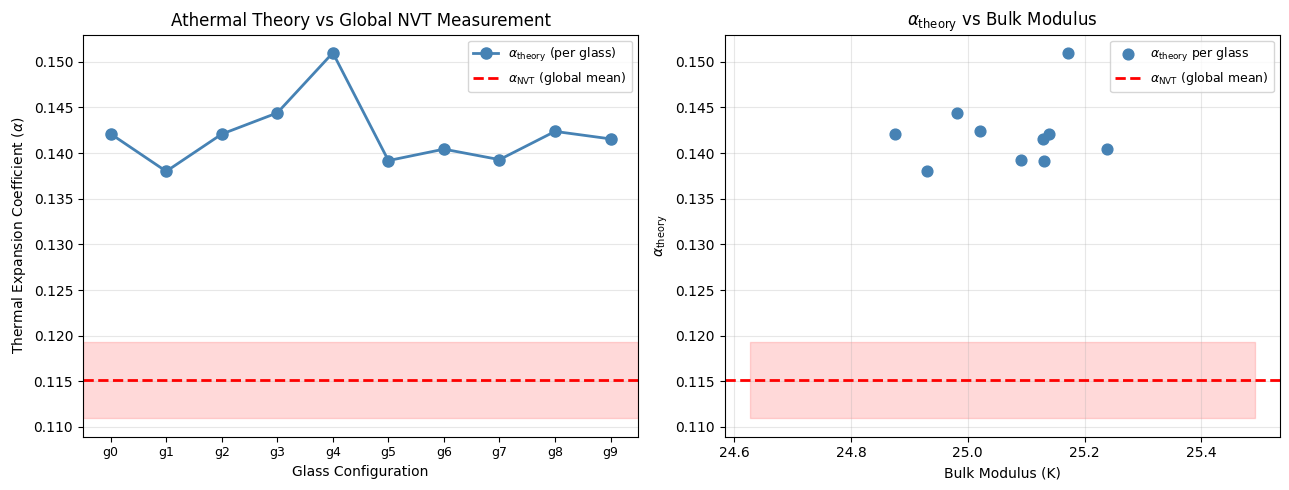

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: alpha theory vs glass index
ax = axes[0]
x = np.arange(len(GLASSES))
ax.plot(x, alpha_theory, 'o-', color='steelblue', lw=2, markersize=8, label=r'$\alpha_{\rm theory}$ (per glass)')

# Plot global NVT baseline
ax.axhline(alpha, color='red', lw=2, ls='--', label=r'$\alpha_{\rm NVT}$ (global mean)')
ax.fill_between([-0.5, len(GLASSES) - 0.5], alpha - alpha_err, alpha + alpha_err, color='red', alpha=0.15)

ax.set_xticks(x)
ax.set_xticklabels([f'g{g}' for g in GLASSES], fontsize=9)
ax.set_xlabel('Glass Configuration')
ax.set_ylabel(r'Thermal Expansion Coefficient ($\alpha$)')
ax.set_title('Athermal Theory vs Global NVT Measurement')
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
ax.set_xlim(-0.5, len(GLASSES) - 0.5)

# Plot 2: alpha theory vs Bulk Modulus (K)
ax2 = axes[1]
ax2.scatter(K, alpha_theory, s=60, color='steelblue', zorder=3, label=r'$\alpha_{\rm theory}$ per glass')

# Plot global NVT baseline
ax2.axhline(alpha, color='red', lw=2, ls='--', label=r'$\alpha_{\rm NVT}$ (global mean)')
ax2.fill_between([K.min()*0.99, K.max()*1.01], alpha - alpha_err, alpha + alpha_err, color='red', alpha=0.15)

ax2.set_xlabel('Bulk Modulus (K)')
ax2.set_ylabel(r'$\alpha_{\rm theory}$')
ax2.set_title(r'$\alpha_{\rm theory}$ vs Bulk Modulus')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Checking plot against NVT for each glass individually instead of globan alpha NVT (curiosity)

In [ ]:
# Per-glass NVT alpha analysis
# Instead of a global average, we fit P_vir(T) independently for each glass
# to see the glass-to-glass fluctuations.

alpha_NVT_per_glass = np.full(len(serials), np.nan)
dPdT_per_glass      = np.full(len(serials), np.nan)

print(f"{'Glass':>6}  {'dP/dT (per glass)':>20}  {'K':>10}  {'alpha_NVT':>12}")
print("-" * 56)

for g in GLASSES:
    T_g, P_g = [], []
    for T in TEMPERATURES:
        f = Path(DATA_DIR) / f'nvt_lj_T{T:.4f}_g{g}.dat'
        if f.exists():
            Tm, Pm, _ = read_nvt(f) # Re-uses your existing read_nvt function
            T_g.append(Tm); P_g.append(Pm)
            
    if len(T_g) < 2:
        continue
        
    T_g, P_g = np.array(T_g), np.array(P_g)
    
    # Perform linear fit for this specific glass
    c = np.polyfit(T_g, P_g, 1)
    dPdT_g = c[0]
    
    # Calculate alpha using this glass's specific K value
    # Assumes 'K' is the array of bulk moduli loaded from elasticity_results.txt
    a_g    = dPdT_g / K[g] 
    
    dPdT_per_glass[g]      = dPdT_g
    alpha_NVT_per_glass[g] = a_g
    print(f"{g:>6}  {dPdT_g:>20.6f}  {K[g]:>10.5f}  {a_g:>12.6f}")

print("-" * 56)
valid = ~np.isnan(alpha_NVT_per_glass)
print(f"{'Mean':>6}  {dPdT_per_glass[valid].mean():>20.6f}  "
      f"{K[valid].mean():>10.5f}  {alpha_NVT_per_glass[valid].mean():>12.6f}")

 Glass     dP/dT (per glass)           K     alpha_NVT
--------------------------------------------------------
     0              2.742408    25.13948      0.109088
     1              3.276642    24.93104      0.131428
     2              3.598228    24.87555      0.144649
     3              2.614331    24.98168      0.104650
     4              2.561672    25.17090      0.101771
     5              2.946915    25.13052      0.117264
     6              2.865687    25.23917      0.113541
     7              3.085459    25.09090      0.122971
     8              2.404591    25.02117      0.096102
     9              2.369365    25.12921      0.094287
--------------------------------------------------------
  Mean              2.846530    25.07096      0.113575


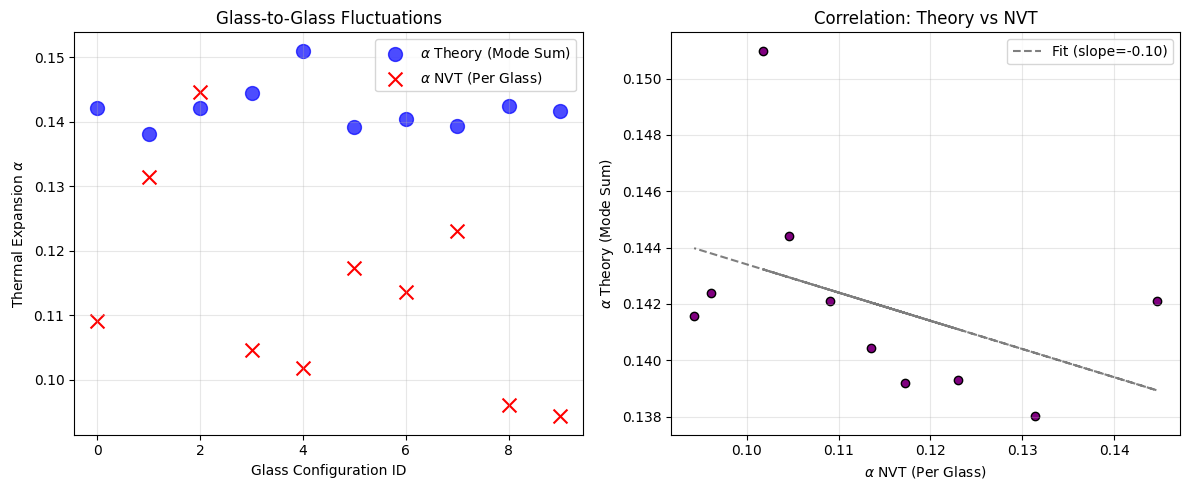

In [ ]:
#Visualization of Per-Glass Fluctuations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Bar/Scatter comparison across glass configurations
x_idx = np.arange(len(GLASSES))
ax1.scatter(x_idx, alpha_theory, s=100, marker='o', label=r'$\alpha$ Theory (Mode Sum)', color='blue', alpha=0.7)
ax1.scatter(x_idx, alpha_NVT_per_glass, s=100, marker='x', label=r'$\alpha$ NVT (Per Glass)', color='red')

ax1.set_xlabel('Glass Configuration ID')
ax1.set_ylabel(r'Thermal Expansion $\alpha$')
ax1.set_title('Glass-to-Glass Fluctuations')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Correlation Plot
mask = ~np.isnan(alpha_NVT_per_glass) & ~np.isnan(alpha_theory)
nvt_vals = alpha_NVT_per_glass[mask]
th_vals = alpha_theory[mask]

ax2.scatter(nvt_vals, th_vals, color='purple', edgecolors='k')

# Add linear regression line to show correlation
m, b = np.polyfit(nvt_vals, th_vals, 1)
ax2.plot(nvt_vals, m * nvt_vals + b, 'k--', alpha=0.5, label=f'Fit (slope={m:.2f})')

ax2.set_xlabel(r'$\alpha$ NVT (Per Glass)')
ax2.set_ylabel(r'$\alpha$ Theory (Mode Sum)')
ax2.set_title('Correlation: Theory vs NVT')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()